<a href="https://colab.research.google.com/github/Ayush-Nandapure/ML/blob/main/heartdiseasepredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


In [2]:
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("heart_disease_uci.csv")

In [5]:
from ydata_profiling import ProfileReport
prof = ProfileReport(df)
prof.to_file(output_file='output.html')

/tmp/ipykernel_518/484759429.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 16/16 [00:00<00:00, 40.22it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [66]:
df['num'] = np.where(df['num'] > 0, 1, 0)

In [67]:
df1 = df.drop(columns = ['id', 'dataset', 'ca', 'thal'])

In [68]:
df1['chol'] = df1['chol'].replace(0, np.nan)

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df1.drop(columns = ['num']), df['num'], test_size = 0.2, random_state = 42)

In [70]:
q1 = X_train['trestbps'].quantile(0.25)
q3 = X_train['trestbps'].quantile(0.75)
iqr = q3- q1
min = q1 - 1.5 * iqr
max = q3 + 1.5  * iqr

In [71]:
X_train['trestbps'] = np.where(X_train['trestbps'] > max, max, np.where(X_train['trestbps'] < min, min, X_train['trestbps']))

In [72]:
X_train.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope
642,53,Male,asymptomatic,125.0,NaN,NaN,normal,120.0,False,1.5,upsloping
298,45,Male,typical angina,110.0,264.0,False,normal,132.0,False,1.2,flat
655,56,Male,asymptomatic,115.0,NaN,NaN,st-t abnormality,82.0,False,-1.0,upsloping
579,59,Male,asymptomatic,140.0,264.0,True,lv hypertrophy,119.0,True,0.0,NaN
728,60,Male,non-anginal,120.0,NaN,NaN,normal,141.0,True,2.0,upsloping


In [73]:
from sklearn.impute import KNNImputer, SimpleImputer

In [74]:
from sklearn.compose import ColumnTransformer

In [75]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, OrdinalEncoder

In [76]:
from sklearn.pipeline import Pipeline

In [77]:
#['chol' , 'oldpeak', 'thalch']
group1 = Pipeline([
    ('num', KNNImputer(n_neighbors = 5, weights = 'distance')),
    ('scale',StandardScaler())
])

In [78]:
#['cp', 'restecg']
group2 = Pipeline([
    ('cat', SimpleImputer(strategy = 'most_frequent')),
    ('encode', OneHotEncoder(drop = 'first', sparse_output= False))
])

In [79]:
#tresbps
group3 = Pipeline([
    ('num', KNNImputer(n_neighbors = 5, weights = 'distance')),
    ('transform', PowerTransformer()),
    ('scale',StandardScaler())
])

In [80]:
#age
group4 = Pipeline([
    ('scale',StandardScaler())
])

In [81]:
#slope
group5 = Pipeline([
    ('impute', SimpleImputer(strategy = 'most_frequent')),
    ('ordinal', OrdinalEncoder(categories = [['downsloping', 'flat', 'upsloping']]))
])

In [82]:
#exang,fbs
group6 = Pipeline([
    ('impute', SimpleImputer(strategy = 'most_frequent'))
])

In [83]:
#sex
group7 = Pipeline([
    ('encode', OneHotEncoder(drop = 'first', sparse_output= False))
])

In [84]:
trf = ColumnTransformer([
    ('group1', group1, ['chol' , 'oldpeak', 'thalch']),
    ('group2', group2, ['cp', 'restecg']),
    ('group3', group3, ['trestbps']),
    ('group4', group4, ['age']),
    ('group5', group5, ['slope']),
    ('group6', group6, ['exang', 'fbs']),
    ('group7', group7, ['sex'])
])

In [85]:
from sklearn.decomposition import PCA


In [86]:
pca = PCA(n_components = None)

In [87]:
from sklearn.linear_model import LogisticRegression

In [88]:
lg = LogisticRegression(max_iter = 1000)

In [89]:
pipe = Pipeline([
  ('trf', trf),
  ('pca', pca),
  ('lg', lg)
])


In [90]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('trf',
                 ColumnTransformer(transformers=[('group1',
                                                  Pipeline(steps=[('num',
                                                                   KNNImputer(weights='distance')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['chol', 'oldpeak',
                                                   'thalch']),
                                                 ('group2',
                                                  Pipeline(steps=[('cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['cp', 'restecg']),
                                                 ('group3',
                                                  Pipeline(...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['downsloping',
                                                                                               'flat',
                                                                                               'upsloping']]))]),
                                                  ['slope']),
                                                 ('group6',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['exang', 'fbs']),
                                                 ('group7',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['sex'])])),
                ('pca', PCA()), ('lg', LogisticRegression(max_iter=1000))])

In [91]:
y_pred = pipe.predict(X_test)

In [92]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve

In [93]:
confusion_matrix(y_test,y_pred)

array([[59, 16],
       [18, 91]])

In [116]:
accuracy_score(y_test, y_pred)

0.8152173913043478

In [98]:
y_scores = pipe.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
j_scores = tpr - fpr
best_index = np.argmax(j_scores)
best_threshold = thresholds[best_index]

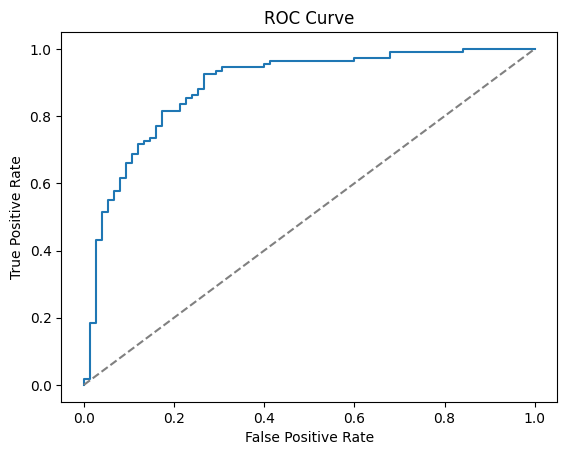

In [99]:
plt.plot(fpr, tpr, label="Logistic Regression ROC")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [100]:
best_threshold

np.float64(0.35566006214678314)

In [113]:
y_pred_2 = (y_scores >= best_threshold).astype(int)

In [114]:
confusion_matrix(y_test, y_pred_2)

array([[ 55,  20],
       [  8, 101]])